### Import bibliotek

In [15]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 1
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


ADOPTION_SPEED_LABELS = {
    0: '0–7',
    1: '8–30',
    2: '31–90',
    3: '>100',
}
ADOPTION_SPEED_ORDER = [ADOPTION_SPEED_LABELS[i] for i in range(4)]

### Wczytanie danych

In [16]:
INPUT_PATH = '../data/processed/train_clean.csv'
OUTPUT_PATH = '../data/processed/train_clean_anomaly.csv'

FEATURE_COLS = ['Age', 'Fee', 'Quantity', 'PhotoAmt', 'DescLength']

df = pd.read_csv(INPUT_PATH)
shape_before = df.shape

print('Podglad danych:')
display(df.head())

print(f'\nShape: {df.shape}')

Podglad danych:


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Dewormed,Sterilized,Health,Quantity,Fee,VideoAmt,PhotoAmt,AdoptionSpeed,HasName,DescLength
0,2,3,299,0,1,1,7,0,1,1,...,2,2,1,1,100,0,1.0,1,1,359
1,2,1,265,0,1,1,2,0,2,2,...,3,3,1,1,0,0,2.0,0,1,118
2,1,1,307,0,1,2,7,0,2,2,...,1,2,1,1,0,0,7.0,2,1,393
3,1,4,307,0,2,1,2,0,2,1,...,1,2,1,1,150,0,8.0,1,1,146
4,1,1,307,0,1,1,0,0,2,1,...,2,2,1,1,0,0,3.0,1,1,390



Shape: (14844, 21)


### Isolation Forest

In [17]:
X = df[FEATURE_COLS].copy()

# Skalowanie cech
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=RANDOM_STATE,
)
iso_forest.fit(X_scaled)

# -1 = anomalia, 1 = normalny rekord
predictions = iso_forest.predict(X_scaled)
df['is_anomaly'] = (predictions == -1).astype(int)

n_anomalies = df['is_anomaly'].sum()
pct_anomalies = n_anomalies / len(df) * 100

print(f'Wykryte anomalie: {n_anomalies}')
print(f'Udział anomalii: {pct_anomalies:.2f}%')

Wykryte anomalie: 743
Udział anomalii: 5.01%


### Wizualizacje anomalii

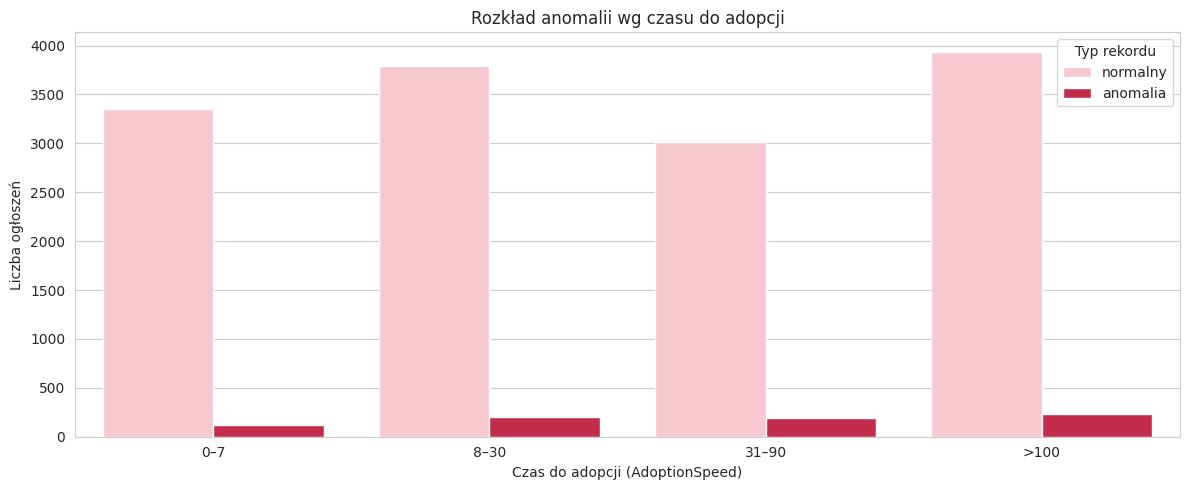

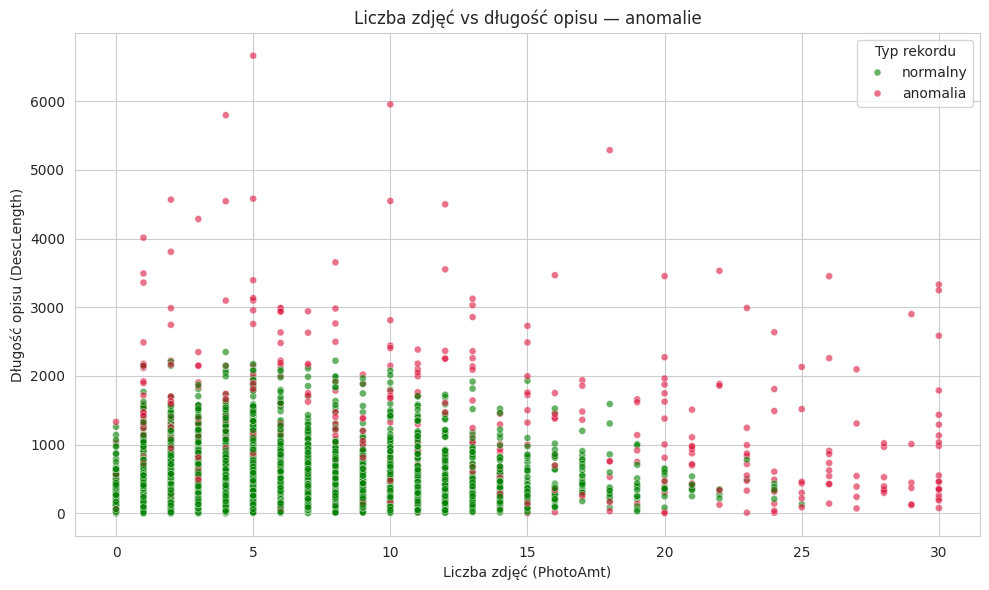

In [18]:
df_plot = df.assign(
    Typ_rekordu=df['is_anomaly'].map({0: 'normalny', 1: 'anomalia'}),
    Czas_adopcji=df['AdoptionSpeed'].map(ADOPTION_SPEED_LABELS),
)
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_plot,
    x='Czas_adopcji',
    hue='Typ_rekordu',
    order=ADOPTION_SPEED_ORDER,
    palette={"normalny": "pink", "anomalia": "crimson"},
)
plt.title('Rozkład anomalii wg czasu do adopcji')
plt.xlabel('Czas do adopcji (AdoptionSpeed)')
plt.ylabel('Liczba ogłoszeń')
plt.legend(title='Typ rekordu')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='PhotoAmt',
    y='DescLength',
    hue='Typ_rekordu',
    palette={"normalny": "green", "anomalia": "crimson"},
    alpha=0.6,
    s=25,
)
plt.title('Liczba zdjęć vs długość opisu — anomalie')
plt.xlabel('Liczba zdjęć (PhotoAmt)')
plt.ylabel('Długość opisu (DescLength)')
plt.legend(title='Typ rekordu')
plt.tight_layout()
plt.show()

### Przeglad anomalii

In [19]:
cols_preview = [
     'Type', 'Age', 'Fee', 'Quantity', 'PhotoAmt',
    'DescLength', 'HasName', 'AdoptionSpeed', 'is_anomaly',
]
cols_preview = [c for c in cols_preview if c in df.columns]

print('10 przykładowych rekordów z is_anomaly=1:')
display(df.loc[df['is_anomaly'] == 1, cols_preview].head(10))

10 przykładowych rekordów z is_anomaly=1:


,Type,Age,Fee,Quantity,PhotoAmt,DescLength,HasName,AdoptionSpeed,is_anomaly
22,2,0,0,10,0.0,111,1,3,1
64,1,2,0,7,21.0,874,1,2,1
74,1,1,100,9,5.0,1878,1,1,1
81,1,3,750,1,2.0,246,1,0,1
113,1,120,0,1,3.0,884,0,3,1
122,1,12,400,1,1.0,1146,1,1,1
145,1,120,0,2,1.0,71,0,0,1
159,2,1,0,3,13.0,2140,1,1,1
165,2,36,0,5,0.0,659,0,3,1
181,2,72,0,1,10.0,1671,1,3,1


### Zapis przetworzonych danych

In [20]:
shape_after = df.shape
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)

print(f'Shape przed dodaniem is_anomaly: {shape_before}')
print(f'Shape po dodaniu is_anomaly: {shape_after}')
print(f'Zapisano: {OUTPUT_PATH}')

Shape przed dodaniem is_anomaly: (14844, 21)
Shape po dodaniu is_anomaly: (14844, 22)
Zapisano: ../data/processed/train_clean_anomaly.csv
